# Importing Necessary Libraries:

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing import timeseries_dataset_from_array
from tensorflow.keras.models import Sequential
from tensorflow.keras import Model
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Lambda, Conv1D, LSTM, Input, add, subtract
from tensorflow.keras.metrics import mae
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# Importing Data:

In [2]:
df = pd.read_csv("Bitcoin Historical Data.csv", parse_dates= ["Date"], index_col= ["Date"], 
                 dayfirst= True)

In [3]:
df.head()

,Price,Open,High,Low,Vol.,Change %
Date,,,,,,
2024-05-29,"67,813.0","68,366.2","68,897.6","67,613.2",57.48K,-0.81%
2024-05-28,"68,366.0","69,428.3","69,560.7","67,299.9",71.39K,-1.53%
2024-05-27,"69,428.7","68,514.6","70,638.3","68,275.2",49.07K,1.33%
2024-05-26,"68,514.8","69,287.2","69,494.0","68,294.5",24.58K,-1.11%
2024-05-25,"69,284.4","68,548.2","69,558.8","68,516.1",25.17K,1.07%


In [4]:
df.index

DatetimeIndex(['2024-05-29', '2024-05-28', '2024-05-27', '2024-05-26',
               '2024-05-25', '2024-05-24', '2024-05-23', '2024-05-22',
               '2024-05-21', '2024-05-20',
               ...
               '2014-06-07', '2014-06-06', '2014-06-05', '2014-06-04',
               '2014-06-03', '2014-06-02', '2014-06-01', '2014-05-31',
               '2014-05-30', '2014-05-29'],
              dtype='datetime64[ns]', name='Date', length=3654, freq=None)

In [5]:
df.shape

(3654, 6)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3654 entries, 2024-05-29 to 2014-05-29
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Price     3654 non-null   object
 1   Open      3654 non-null   object
 2   High      3654 non-null   object
 3   Low       3654 non-null   object
 4   Vol.      3654 non-null   object
 5   Change %  3654 non-null   object
dtypes: object(6)
memory usage: 199.8+ KB


In [7]:
df = df.sort_index(ascending= True)

In [8]:
# Taking Only Price Column for Modelling:
bitcoin_prices = pd.DataFrame(df["Price"])

In [9]:
bitcoin_prices.head()

,Price
Date,
2014-05-29,564.4
2014-05-30,612.3
2014-05-31,627.9
2014-06-01,649.8
2014-06-02,655.5


In [10]:
bitcoin_prices.shape

(3654, 1)

In [11]:
bitcoin_prices.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3654 entries, 2014-05-29 to 2024-05-29
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Price   3654 non-null   object
dtypes: object(1)
memory usage: 57.1+ KB


In [12]:
bitcoin_prices["Price"] = bitcoin_prices["Price"].str.replace(",", "").astype("float")

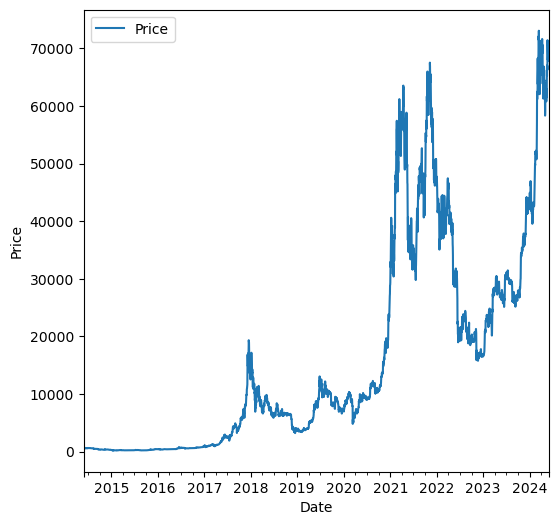

In [13]:
# Plotting time Series:
bitcoin_prices.plot(figsize= (6,6))
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

# Train Test Split:

In [14]:
# getting Dates and Prices into Arrays:
timesteps = bitcoin_prices.index.to_numpy()
prices = bitcoin_prices["Price"].to_numpy()

In [15]:
split_size = int(0.8 * len(bitcoin_prices))

# Training Data:
x_train, y_train = timesteps[:split_size], prices[:split_size]

# Test Data:
x_test, y_test = timesteps[split_size:], prices[split_size:]

x_train.shape, x_test.shape, y_train.shape, y_test.shape

((2923,), (731,), (2923,), (731,))

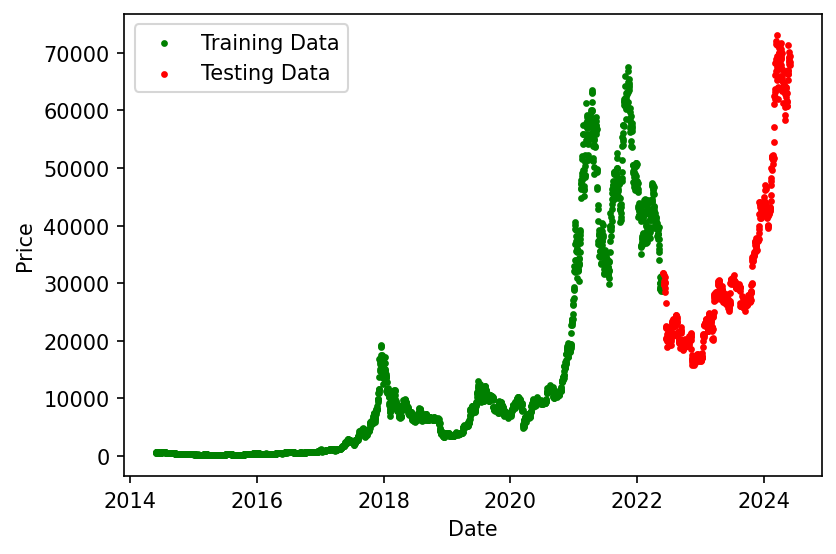

In [16]:
# Plotting Training and Test Data:
plt.figure(figsize= (6,4), dpi= 150)
plt.scatter(x_train, y_train, c= "green", s= 5, label= "Training Data")
plt.scatter(x_test, y_test, c= "red", s= 5, label= "Testing Data")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

In [27]:
x_train[:5], x_test[:5], y_train[:5], y_test[:5]

(array(['2014-05-29T00:00:00.000000000', '2014-05-30T00:00:00.000000000',
        '2014-05-31T00:00:00.000000000', '2014-06-01T00:00:00.000000000',
        '2014-06-02T00:00:00.000000000'], dtype='datetime64[ns]'),
 array(['2022-05-30T00:00:00.000000000', '2022-05-31T00:00:00.000000000',
        '2022-06-01T00:00:00.000000000', '2022-06-02T00:00:00.000000000',
        '2022-06-03T00:00:00.000000000'], dtype='datetime64[ns]'),
 array([564.4, 612.3, 627.9, 649.8, 655.5]),
 array([31723.3, 31793.4, 29798.5, 30455.5, 29700.9]))

# Time-Series Data Generators:

In [24]:
WINDOW_SIZE= 14 # Using Last 14 Days of Data to Predict
HORIZON= 1 # Predict Next 1 Day

In [26]:
prices

array([  564.4,   612.3,   627.9, ..., 69428.7, 68366. , 67813. ])

In [33]:
training_data = timeseries_dataset_from_array(data= y_train,
                                             targets= y_train[WINDOW_SIZE:],
                                             sequence_length= WINDOW_SIZE,
                                             sequence_stride= HORIZON)

test_data = timeseries_dataset_from_array(data= y_test,
                                         targets= y_test[WINDOW_SIZE:],
                                         sequence_length= WINDOW_SIZE,
                                         sequence_stride= HORIZON)

In [34]:
training_data, test_data

(<_BatchDataset element_spec=(TensorSpec(shape=(None, None), dtype=tf.float64, name=None), TensorSpec(shape=(None,), dtype=tf.float64, name=None))>,
 <_BatchDataset element_spec=(TensorSpec(shape=(None, None), dtype=tf.float64, name=None), TensorSpec(shape=(None,), dtype=tf.float64, name=None))>)

In [35]:
training_data.take(1)

<_TakeDataset element_spec=(TensorSpec(shape=(None, None), dtype=tf.float64, name=None), TensorSpec(shape=(None,), dtype=tf.float64, name=None))>

In [40]:
for x,y in training_data.take(1):
    print(x)
    print(y)

tf.Tensor(
[[564.4 612.3 627.9 ... 644.3 655.6 643. ]
 [612.3 627.9 649.8 ... 655.6 643.  597.1]
 [627.9 649.8 655.5 ... 643.  597.1 610.3]
 ...
 [382.8 375.1 363.5 ... 373.2 387.3 397.1]
 [375.1 363.5 335.3 ... 387.3 397.1 393.2]
 [363.5 335.3 322.9 ... 397.1 393.2 379.8]], shape=(128, 14), dtype=float64)
tf.Tensor(
[597.1 610.3 583.4 582.3 599.1 605.1 606.2 600.2 590.8 597.  603.6 591.2
 588.8 568.5 582.7 602.2 597.6 601.1 635.1 643.2 645.7 638.  624.  623.
 626.7 613.6 615.3 623.  618.4 632.9 635.9 628.  618.3 619.6 614.8 626.6
 627.5 627.  621.  625.1 622.5 621.7 601.9 600.5 596.  595.  587.9 585.8
 564.6 589.5 598.8 591.7 588.9 592.8 588.8 589.8 592.8 595.8 589.5 592.1
 575.9 567.7 542.1 504.8 496.5 522.  485.5 462.2 485.1 516.8 517.9 516.1
 497.7 509.7 502.9 512.6 515.2 510.8 512.6 506.  481.8 477.2 478.9 480.
 491.  483.6 484.5 485.8 475.7 474.9 479.7 478.5 477.7 478.2 477.7 477.7
 466.8 461.1 424.3 397.7 411.5 401.6 404.1 436.9 423.8 412.3 404.5 399.
 379.1 376.8 388.2 382.8 37

# Creating Model:

In [42]:
tf.random.set_seed(42)

inputs = Input(shape= (WINDOW_SIZE,1), name= "Input_Layer")
x = LSTM(64, activation= "relu", return_sequences= True)(inputs)
x = LSTM(32, activation= "relu")(x)
x = Dense(16, activation= "relu")(x)
output = Dense(HORIZON)(x)

model1 = Model(inputs, output)

# Compiling The Model:
model1.compile(optimizer= Adam(),
              loss= mae,
              metrics= ["mae"])

# Fitting The Model:
history1 = model1.fit(training_data,
                     validation_data= test_data,
                     epochs= 100)

Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 2667.6992 - mae: 2667.6992 - val_loss: 15977.0029 - val_mae: 15977.0029
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1179.5610 - mae: 1179.5610 - val_loss: 2932.4119 - val_mae: 2932.4119
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 496.3766 - mae: 496.3766 - val_loss: 5060.0190 - val_mae: 5060.0190
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 754.8806 - mae: 754.8806 - val_loss: 8154.9268 - val_mae: 8154.9268
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 783.9243 - mae: 783.9243 - val_loss: 2568.0383 - val_mae: 2568.0383
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 707.2273 - mae: 707.2273 - val_loss: 2058.4062 - val_mae: 2058.4062
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 782.3616 - mae: 782.3616 - val_loss: 2103.3491 - val_mae: 2103.3491
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 799.1668 - mae: 799.1668 - val_loss: 3

# Model Evaluation:

In [45]:
model1_preds = model1.predict(test_data)

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step


In [46]:
model1_preds

array([[30708.805],
       [30542.85 ],
       [30196.758],
       [30105.764],
       [29824.252],
       [29488.326],
       [29074.74 ],
       [28549.781],
       [27602.666],
       [26529.268],
       [25655.572],
       [24623.861],
       [23367.002],
       [22140.96 ],
       [21282.334],
       [21021.9  ],
       [20877.004],
       [20496.996],
       [20613.764],
       [20630.805],
       [20881.592],
       [20875.25 ],
       [20877.215],
       [20759.67 ],
       [20817.68 ],
       [20697.238],
       [20538.275],
       [20331.291],
       [20186.97 ],
       [20169.818],
       [20166.76 ],
       [20222.787],
       [20310.715],
       [20515.79 ],
       [20726.816],
       [20930.334],
       [20948.832],
       [21016.166],
       [21065.291],
       [20978.824],
       [20983.396],
       [20935.484],
       [21041.678],
       [21305.656],
       [21697.268],
       [22001.338],
       [22265.666],
       [22516.486],
       [22713.012],
       [22925.252],


In [47]:
model1_preds.shape

(717, 1)

In [48]:
y_test.shape

(731,)

In [49]:
y_test[:-14].shape

(717,)

In [50]:
y_test[0]

31723.3

In [52]:
mae_1 = tf.metrics.mean_absolute_error(y_test[:-14], tf.squeeze(model1_preds))
mae_1

<tf.Tensor: shape=(), dtype=float32, numpy=1019.18774>

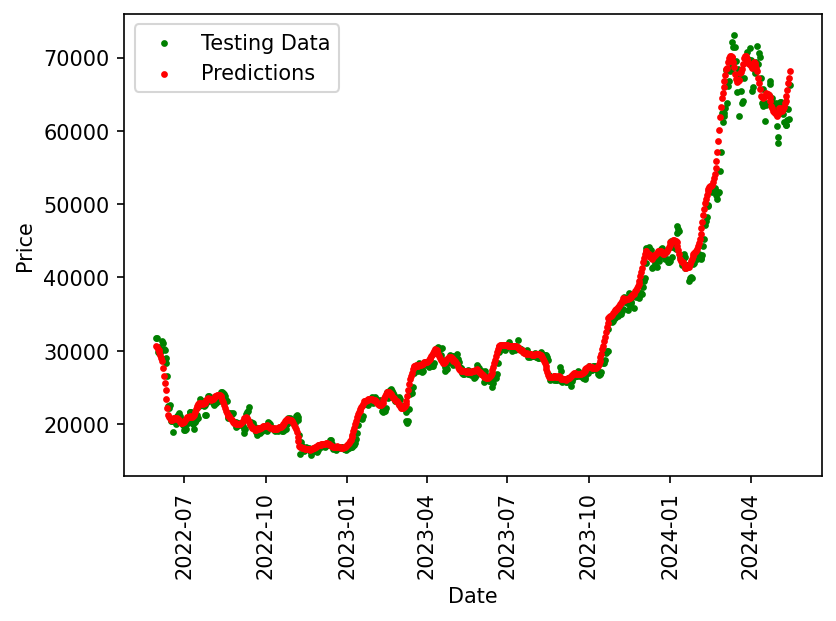

In [54]:
# Plotting Test Data and Predictions:
plt.figure(figsize= (6,4), dpi= 150)
plt.scatter(x_test[:-14], y_test[:-14], c= "green", s= 5, label= "Testing Data")
plt.scatter(x_test[:-14], tf.squeeze(model1_preds), c= "red", s= 5, label= "Predictions")
plt.xlabel("Date")
plt.ylabel("Price")
plt.xticks(rotation= 90)
plt.legend()
plt.show()